
✅ Dataset Loaded Successfully
   User_Type  CPU_Usage  RAM_Usage  Storage  App_Hours  Performance_Rating
0  Developer         69         87      541        5.8               78.29
1    Student         37         32      588        3.6               73.40
2    Student         32         50      588        2.5               81.12
3   Designer         76         96      679        5.1               78.62
4    Student         25         66      178        6.1               74.44

Dataset Shape: (1500, 6)

✅ Data Preprocessing Completed

📊 Model Evaluation
R² Score:  0.89
Mean Squared Error:  4.921


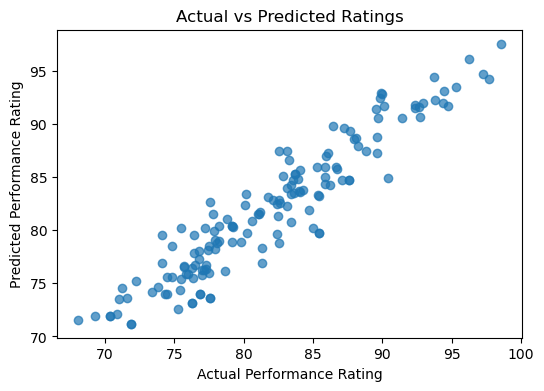


🔮 Enter new user configuration to predict performance rating:


Enter user type (Developer, Designer, Student, Gamer):  Gamer
Enter average CPU Usage (0–100):  22
Enter average RAM Usage (0–100):  24
Enter Storage Used (in GB):  40
Enter App Usage Hours per Day:  5



Predicted Performance Rating: 72.21 / 100



Press Enter to continue or 'q' to quit:  
Enter user type (Developer, Designer, Student, Gamer):  Student
Enter average CPU Usage (0–100):  70
Enter average RAM Usage (0–100):  60
Enter Storage Used (in GB):  90
Enter App Usage Hours per Day:  6



Predicted Performance Rating: 69.46 / 100


In [ ]:
# Software Performance Rating System using KNN Regressor
# -------------------------------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

class LearningAgentKNNRegressor:
    def __init__(self):
        self.df = None
        self.scaler = None
        self.label_encoder = None
        self.model = None

    def load_data(self, file_path):
        """Load dataset from CSV"""
        self.df = pd.read_csv(file_path)
        print("\n✅ Dataset Loaded Successfully")
        print(self.df.head())
        print("\nDataset Shape:", self.df.shape)

    def preprocess_data(self):
        """Encode categorical data and scale numerical features"""
        df = self.df.copy()

        # Encode User_Type
        le = LabelEncoder()
        df['User_Type_Encoded'] = le.fit_transform(df['User_Type'])

        features = df[['User_Type_Encoded', 'CPU_Usage', 'RAM_Usage', 'Storage', 'App_Hours']]
        target = df['Performance_Rating']

        # Split data
        X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.1, random_state=42)

        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        self.label_encoder = le
        self.scaler = scaler
        self.X_train, self.X_test = X_train_scaled, X_test_scaled
        self.y_train, self.y_test = y_train, y_test
        print("\n✅ Data Preprocessing Completed")

    def train_model(self, n_neighbors=3):
        """Train KNN Regressor"""
        knn = KNeighborsRegressor(n_neighbors=n_neighbors)
        knn.fit(self.X_train, self.y_train)
        self.model = knn

        preds = knn.predict(self.X_test)
        r2 = r2_score(self.y_test, preds)
        mse = mean_squared_error(self.y_test, preds)

        print("\n📊 Model Evaluation")
        print("R² Score: ", round(r2, 3))
        print("Mean Squared Error: ", round(mse, 3))

        # Visualization
        plt.figure(figsize=(6, 4))
        plt.scatter(self.y_test, preds, alpha=0.7)
        plt.xlabel("Actual Performance Rating")
        plt.ylabel("Predicted Performance Rating")
        plt.title("Actual vs Predicted Ratings")
        plt.show()

    def predict_new(self):
        """Semi-autonomous mode for new input predictions"""
        print("\n🔮 Enter new user configuration to predict performance rating:")
        while True:
            user_type = input("Enter user type (Developer, Designer, Student, Gamer): ")
            if user_type not in ['Developer', 'Designer', 'Student', 'Gamer']:
                print("Invalid user type. Try again.")
                continue

            cpu = float(input("Enter average CPU Usage (0–100): "))
            ram = float(input("Enter average RAM Usage (0–100): "))
            storage = float(input("Enter Storage Used (in GB): "))
            hours = float(input("Enter App Usage Hours per Day: "))

            user_encoded = self.label_encoder.transform([user_type])
            new_input = pd.DataFrame([[user_encoded[0], cpu, ram, storage, hours]],
                                     columns=['User_Type_Encoded', 'CPU_Usage', 'RAM_Usage', 'Storage', 'App_Hours'])
            new_scaled = self.scaler.transform(new_input)
            prediction = self.model.predict(new_scaled)[0]
            print(f"\nPredicted Performance Rating: {round(prediction, 2)} / 100")

            cont = input("\nPress Enter to continue or 'q' to quit: ")
            if cont.lower() == 'q':
                print("Exiting semi-autonomous mode.")
                break


# ---------------------- DRIVER CODE ------------------------
if __name__ == "__main__":
    agent = LearningAgentKNNRegressor()
    file_path = "Software_Performance_Data_500.csv" 
    agent.load_data(file_path)
    agent.preprocess_data()
    agent.train_model()
    agent.predict_new()
